In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import sys
function_path = './func/'
sys.path.append(function_path)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from visualizaion_func import *

In [24]:
from crmprtd import setup_logging
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

#### Find the stations under network 2, and have all the variables I want

In [19]:
# sql_text = sa.text("""
# SELECT s.station_id, h.station_name
# FROM meta_history h
# JOIN meta_station s
#     ON h.station_id = s.station_id
# WHERE s.network_id = 2

# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'MINIMUM_AIR_TEMPERATURE'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'MAXIMUM_AIR_TEMPERATURE'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'min_air_temp_snc_last_reset'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'max_air_temp_snc_last_reset'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'air_temp'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'pcpn_amt_pst1hr'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'snwfl_amt_pst1hr'
# )
# AND EXISTS (
#     SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
#     WHERE o.history_id = h.history_id AND v.net_var_name = 'snw_dpth'
# )
# ;

# """)

# with engine.begin() as conn:
#     df = pd.read_sql(sql_text, conn)

# df

### Get variables' data

In [ ]:
# stations_2 = df['station_id'].iloc[4:6].tolist()
stations_1 = [2655]
sql_text = sa.text("""
SELECT s.station_id, o.obs_time, v.net_var_name, o.datum
FROM meta_history h
JOIN meta_station s ON h.station_id = s.station_id
JOIN obs_raw o ON o.history_id = h.history_id
JOIN meta_vars v ON o.vars_id = v.vars_id
WHERE s.network_id = 2
AND s.station_id IN :stations
AND v.net_var_name IN (
    'MINIMUM_AIR_TEMPERATURE',
    'MAXIMUM_AIR_TEMPERATURE',
    'min_air_temp_snc_last_reset',
    'max_air_temp_snc_last_reset',
    'air_temp',
    'pcpn_amt_pst1hr',
    'snwfl_amt_pst1hr',
    'snw_dpth'
)
ORDER BY s.station_id, o.obs_time
""")

with engine.begin() as conn:
    df_obs = pd.read_sql(sql_text, conn, params={
                         "stations": tuple(stations_1)})

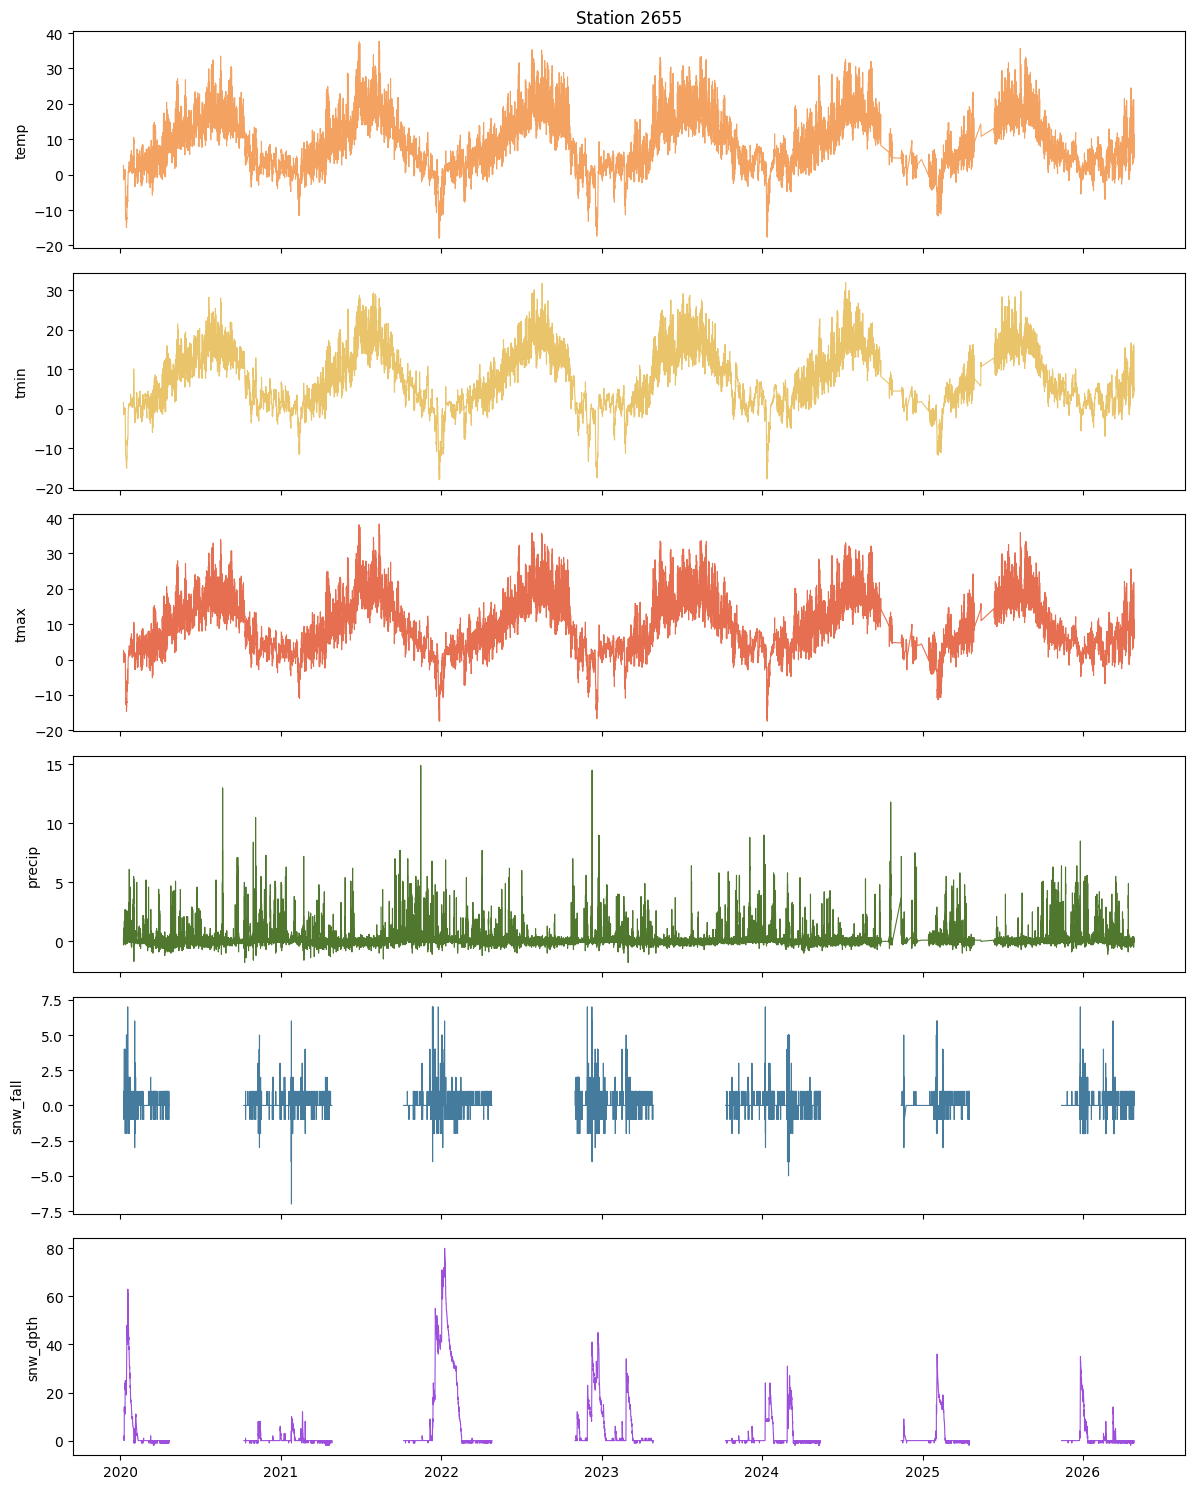

In [41]:
df_sql_list = []

for station_id, df_station in df_obs.groupby("station_id"):

    df_station = df_station.copy()
    df_station["obs_time"] = pd.to_datetime(df_station["obs_time"])

    df_sql = df_station.pivot_table(
        index="obs_time",
        columns="net_var_name",
        values="datum"
    ).sort_index()

    df_sql = df_sql.rename(columns={
        "min_air_temp_snc_last_reset": "tmin",
        "max_air_temp_snc_last_reset": "tmax",
        "air_temp": "temp",
        "pcpn_amt_pst1hr": "precip",
        "snwfl_amt_pst1hr": "snw_fall"
    })

    df_sql_list.append((station_id, df_sql))

stat_id = 0
station_df = df_sql_list[stat_id][1]

station_df = station_df[[
    'temp',
    'tmin',
    'tmax',
    'precip',
    'snw_fall',
    'snw_dpth'
]]

start_time = station_df.apply(lambda col: col.first_valid_index()).min()

station_df_trim = station_df.loc[start_time:]

color_map = {
    "temp": "#f4a261",
    "tmin": "#e9c46a",
    "tmax": "#e76f51",
    "snw_fall": "#457b9d",
    "snw_dpth": "#9d4edd",
    "precip": "#4f772d",
}

plot_weather_data(station_df_trim, color_map=color_map,
                  title=f"Station {station_id}")

### hourly_to_daily data

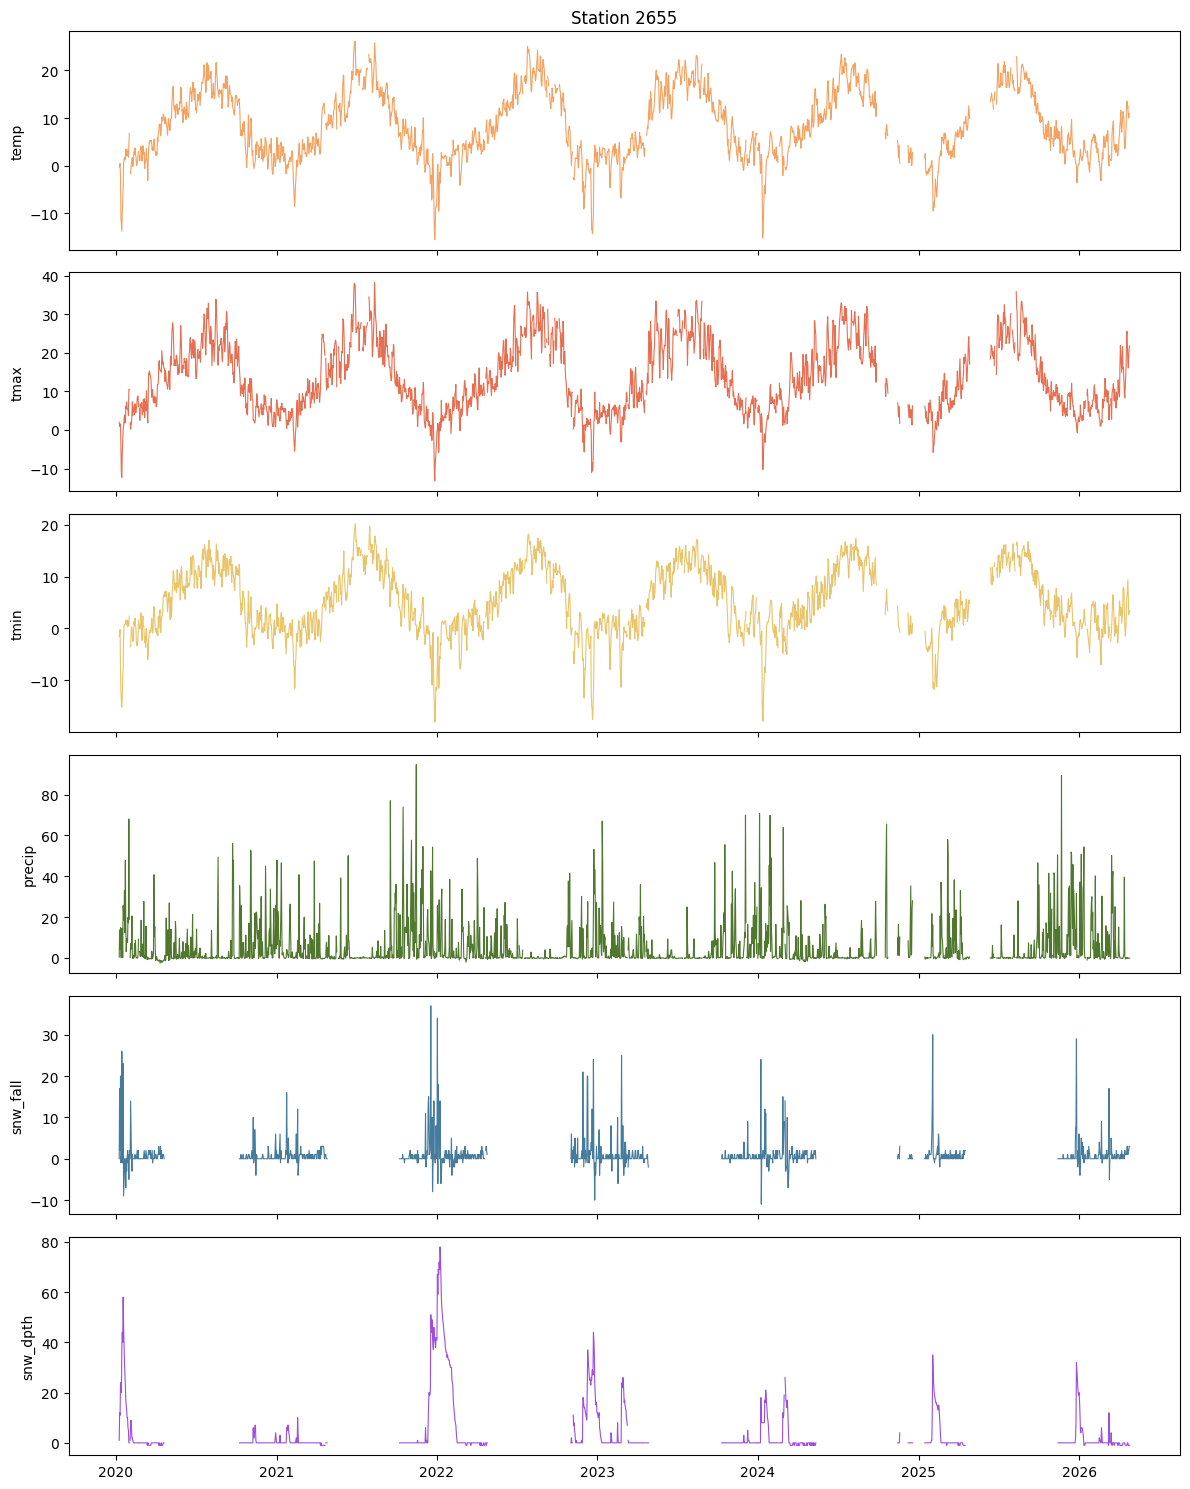

In [102]:
from func_hour_to_daily import *

daily_tas = hourly_to_daily(
    station_df_trim,
    cols=["tmax", "tmin", "temp"],
    agg_map={
        "temp": "mean",
        "tmax": "max",
        "tmin": "min",
    },
    min_hours=18
)


daily_sn = hourly_to_daily(
    station_df_trim,
    cols=["snw_fall", "snw_dpth"],
    agg_map={
        "snw_fall": "sum",
        "snw_dpth": "last",   # usually better than mean
    },
    min_hours=18
)


daily_precip = hourly_to_daily(
    station_df_trim,
    cols=["precip"],
    agg_map={"precip": "sum"},
    min_hours=18   # or 24 if strict
)

daily_all = pd.concat(
    [daily_tas, daily_precip, daily_sn],
    axis=1
)


daily_all

plot_weather_data(daily_all, color_map=color_map,
                  title=f"Station {station_id}")

### 1. Integrity check

#### 1.1 Missing value check


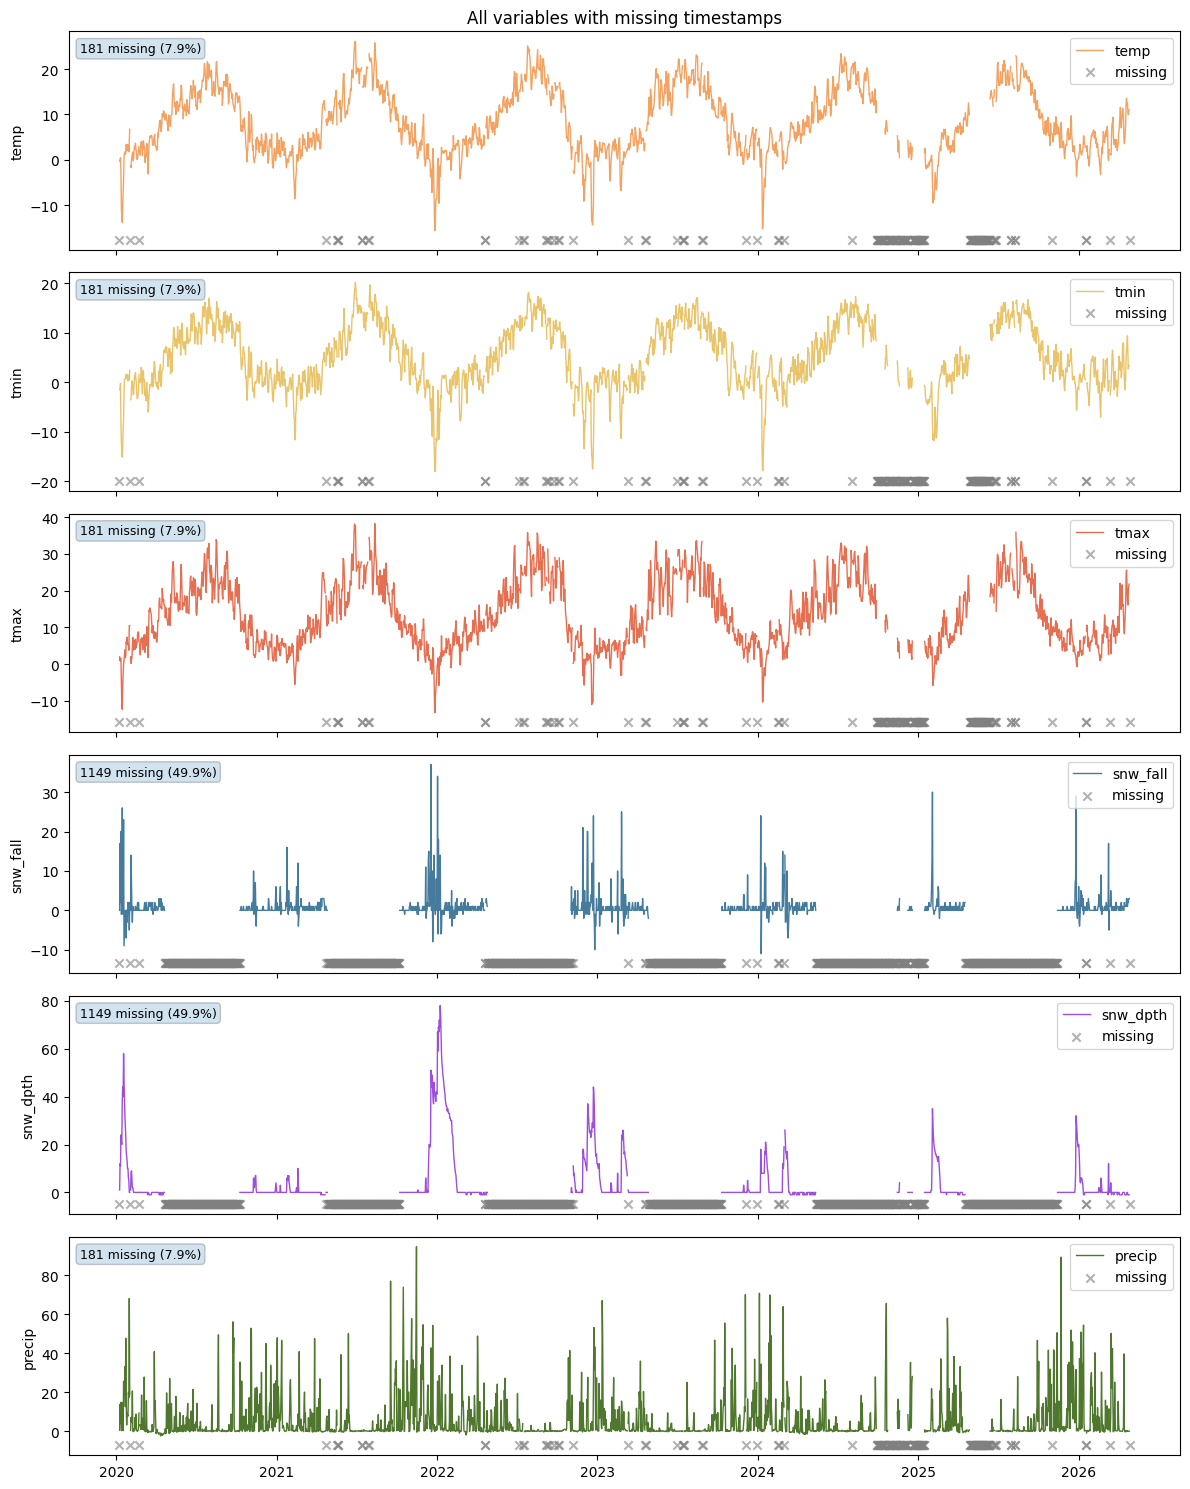

In [ ]:
from func_1_integrity_check import *

value_cols = ["temp", "tmin", "tmax", "snw_fall", "snw_dpth", "precip"]

miss_result_dict = {}

for col in value_cols:
    miss_result_dict[col] = check_missing_timestamps(
        daily_all,
        value_col=col
    )

plot_timeseries_with_missing_multi(
    df=daily_all,
    miss_result_dict=miss_result_dict,
    color_map=color_map,
    value_cols=value_cols,
    title="All variables with missing timestamps"
)

### Naught check

In [166]:
from func_2_naught_check import *

qc_result = qc_naught_and_trace(daily_all)

qc_result["temp_zero"].sum()
qc_result["precip_trace"].sum()

flag_precip_trace    0
dtype: int64

### Duplicate check

Check for
1. Duplicate entire years: “All values in one year = another year”
2. Duplicate months within the same year: “One month = another month”
3. Same calendar month across years: “Jan 2000 = Jan 2001”

4. Identical value–streak checks: •	If the same value repeats for many consecutive days, it’s unusual and probably an error.
	- Example thresholds given:
	- Temperature (TMAX/TMIN): 20 or more consecutive identical values
	- Snowfall (SNOW): 10 or more consecutive identical nonzero values
	- Snow depth (SNWD): 90 or more consecutive identical nonzero values

In [116]:
daily_all

net_var_name,temp,tmax,tmin,precip,snw_fall,snw_dpth
obs_time,,,,,,
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,-0.317391,2.0,-1.5,4.000000e-01,0.0,1.0
2020-01-10,-0.079167,0.9,-1.0,1.370000e+01,17.0,12.0
2020-01-11,0.441667,1.6,-0.2,4.200000e+00,2.0,11.0
2020-01-12,-2.504167,1.5,-8.1,1.480000e+01,20.0,24.0
...,...,...,...,...,...,...
2026-04-23,10.860870,16.1,5.9,-1.000000e-01,2.0,-1.0
2026-04-24,10.004167,19.5,2.7,-1.000000e-01,2.0,-1.0
2026-04-25,10.804167,21.2,3.3,2.775558e-17,3.0,-1.0


In [149]:
from func_2_dunplicate_check import *

value_cols = ["temp", "tmin", "tmax", "snw_fall", "snw_dpth", "precip"]


dup_result_dict = {}

for col in value_cols:

    dup_result_dict[col] = duplicate_check_temperature(
        daily_all,
        value_col=col,
    )

    print(f"\n🔍 Checking variable - {col}")

    print_duplicate_summary(dup_result_dict[col], value_col=col)

    # print(duplicate_summary_for_ppt(dup_result_dict[col], value_col=col))


🔍 Checking variable - temp

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🔴 Identical Value Streaks: None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - tmin

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🔴 Identical Value Streaks: None

🌡️ TMAX–TMIN Flatline Months: None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - tmax

===== DUPLICATE CHECK SUMMARY =====

📅 Duplicate Years: None

📆 Duplicate Months (within year): None

🌍 Duplicate Months (across years): None

🔴 Identical Value Streaks: None

🌡️ TMAX–TMIN Flatline Months: None

---------------------------------
✅ Duplicate check PASSED — no issues found


🔍 Checking variable - snw_fall

===== DUPLICATE CHECK SUMMARY =====

📅 Duplica